In [ ]:
###Evaluation3
#Hier wurden alle Ergebnisse ausgewertet, dargestellt und kontextualisiert. Zusätzlicher Signifikanztest.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Signifikanztests
from scipy.stats import wilcoxon

#Ordner erstellen
os.makedirs("plots", exist_ok=True)

#metrics laden
metrics = pd.read_csv("eval_metrics_100_2.csv")

#Anzahl check
print("Anzahl:", len(metrics))
print(metrics.columns)
metrics.head()

In [3]:
#Zusammenfassung der Evaluationsergebnisse

summary = pd.DataFrame({
    "Metrik": [
        "BERTScore F1",
        "BLEU",
        "ROUGE-L",
        "Antwortlänge Tokens",
        "Emoji-Anzahl"
    ],
    "Referenz": [
        np.nan,
        np.nan,
        np.nan,
        metrics["len_reference_tokens"].mean(),
        metrics["emoji_reference"].mean()
    ],
    "Base": [
        metrics["bertscore_f1_base"].mean(),
        metrics["bleu_base"].mean(),
        metrics["rougeL_base"].mean(),
        metrics["len_base_tokens"].mean(),
        metrics["emoji_base"].mean()
    ],
    "Fine-Tuned": [
        metrics["bertscore_f1_ft"].mean(),
        metrics["bleu_ft"].mean(),
        metrics["rougeL_ft"].mean(),
        metrics["len_ft_tokens"].mean(),
        metrics["emoji_ft"].mean()
    ]
})

summary

,Metrik,Referenz,Base,Fine-Tuned
0,BERTScore F1,NaN,0.542849,0.634173
1,BLEU,NaN,0.001769,0.007298
2,ROUGE-L,NaN,0.022862,0.052191
3,Antwortlänge Tokens,14.52,55.330000,18.690000
4,Emoji-Anzahl,1.29,6.380000,0.580000


In [4]:
summary.to_csv("eval_final_summary.csv", index=False, encoding="utf-8-sig")

In [5]:
#Veränderung der Metriken

delta_summary = pd.DataFrame({
    "Metrik": ["BERTScore F1", "BLEU", "ROUGE-L"],
    "Durchschnitt Base": [
        metrics["bertscore_f1_base"].mean(),
        metrics["bleu_base"].mean(),
        metrics["rougeL_base"].mean()
    ],
    "Durchschnitt Fine-Tuned": [
        metrics["bertscore_f1_ft"].mean(),
        metrics["bleu_ft"].mean(),
        metrics["rougeL_ft"].mean()
    ],
    "Durchschnittliche Veränderung": [
        metrics["delta_bertscore_f1"].mean(),
        metrics["delta_bleu"].mean(),
        metrics["delta_rougeL"].mean()
    ],
    "Anteil FT besser": [
        (metrics["delta_bertscore_f1"] > 0).mean(),
        (metrics["delta_bleu"] > 0).mean(),
        (metrics["delta_rougeL"] > 0).mean()
    ]
})

delta_summary

,Metrik,Durchschnitt Base,Durchschnitt Fine-Tuned,Durchschnittliche Veränderung,Anteil FT besser
0,BERTScore F1,0.542849,0.634173,0.091324,0.91
1,BLEU,0.001769,0.007298,0.005528,0.50
2,ROUGE-L,0.022862,0.052191,0.029329,0.33


In [6]:
metrics["bertscore_f1_ft"].sort_values()

59    0.498639
93    0.518869
86    0.533764
8     0.537217
37    0.538246
        ...   
16    0.726415
72    0.745886
40    0.772957
77    0.780707
24    0.812625
Name: bertscore_f1_ft, Length: 100, dtype: float64

In [7]:
delta_summary.to_csv("eval_delta_summary_2.csv", index=False, encoding="utf-8-sig")

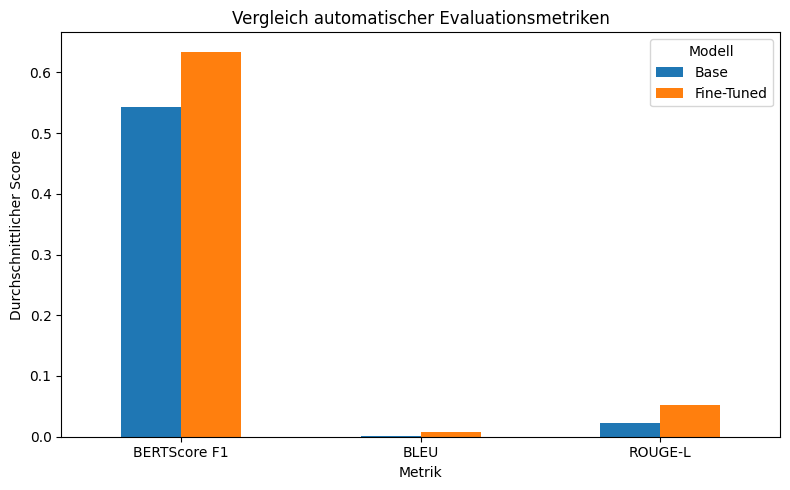

In [8]:
#Mittelwerte der MEtriken

metric_means = pd.DataFrame({
    "Base": [
        metrics["bertscore_f1_base"].mean(),
        metrics["bleu_base"].mean(),
        metrics["rougeL_base"].mean()
    ],
    "Fine-Tuned": [
        metrics["bertscore_f1_ft"].mean(),
        metrics["bleu_ft"].mean(),
        metrics["rougeL_ft"].mean()
    ]
}, index=["BERTScore F1", "BLEU", "ROUGE-L"])

ax = metric_means.plot(kind="bar", figsize=(8, 5))
plt.title("Vergleich automatischer Evaluationsmetriken")
plt.ylabel("Durchschnittlicher Score")
plt.xlabel("Metrik")
plt.xticks(rotation=0)
plt.legend(title="Modell")
plt.tight_layout()

plt.show()

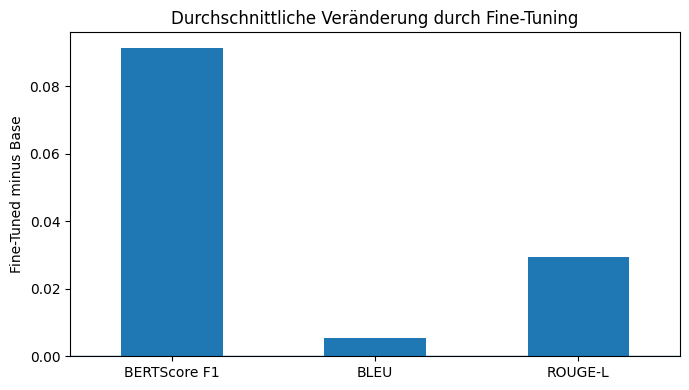

In [9]:
#Plot des der Feintuning-Veränderung

delta_means = pd.Series({
    "BERTScore F1": metrics["delta_bertscore_f1"].mean(),
    "BLEU": metrics["delta_bleu"].mean(),
    "ROUGE-L": metrics["delta_rougeL"].mean()
})

plt.figure(figsize=(7, 4))
delta_means.plot(kind="bar")
plt.axhline(0, linewidth=1)
plt.title("Durchschnittliche Veränderung durch Fine-Tuning")
plt.ylabel("Fine-Tuned minus Base")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

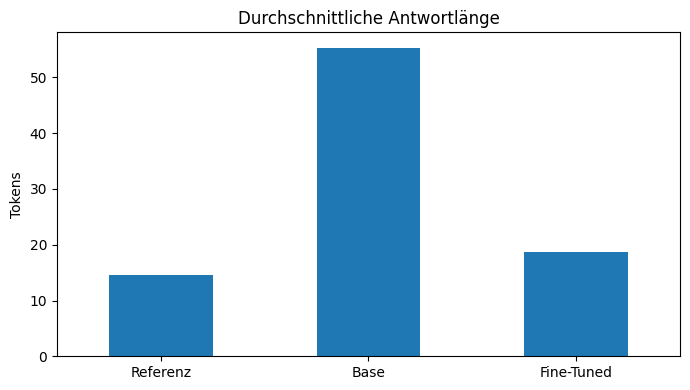

In [10]:
#Plot der Antwortlänge

length_means = pd.Series({
    "Referenz": metrics["len_reference_tokens"].mean(),
    "Base": metrics["len_base_tokens"].mean(),
    "Fine-Tuned": metrics["len_ft_tokens"].mean()
})

plt.figure(figsize=(7, 4))
length_means.plot(kind="bar")
plt.title("Durchschnittliche Antwortlänge")
plt.ylabel("Tokens")
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig("plots/answer_length_comparison.png", dpi=300)
plt.show()

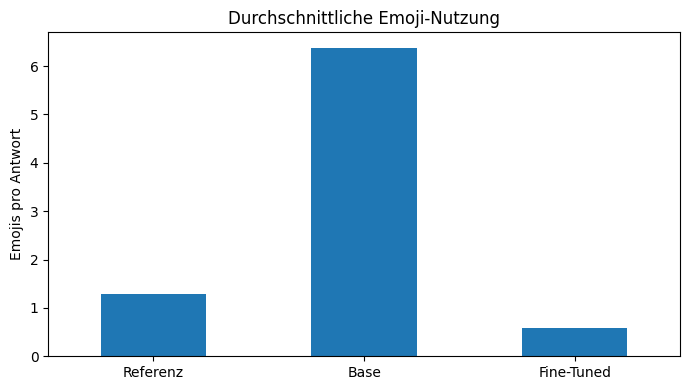

In [11]:
#Plot der Emoji Nutzung

emoji_means = pd.Series({
    "Referenz": metrics["emoji_reference"].mean(),
    "Base": metrics["emoji_base"].mean(),
    "Fine-Tuned": metrics["emoji_ft"].mean()
})

plt.figure(figsize=(7, 4))
emoji_means.plot(kind="bar")
plt.title("Durchschnittliche Emoji-Nutzung")
plt.ylabel("Emojis pro Antwort")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

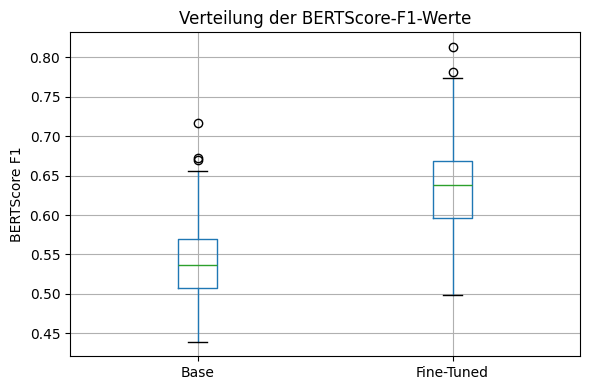

In [12]:
#Plot der BERTScore F1 Werte
bertscore_box = pd.DataFrame({
    "Base": metrics["bertscore_f1_base"],
    "Fine-Tuned": metrics["bertscore_f1_ft"]
})

plt.figure(figsize=(6, 4))
bertscore_box.boxplot()
plt.title("Verteilung der BERTScore-F1-Werte")
plt.ylabel("BERTScore F1")
plt.tight_layout()
plt.show()

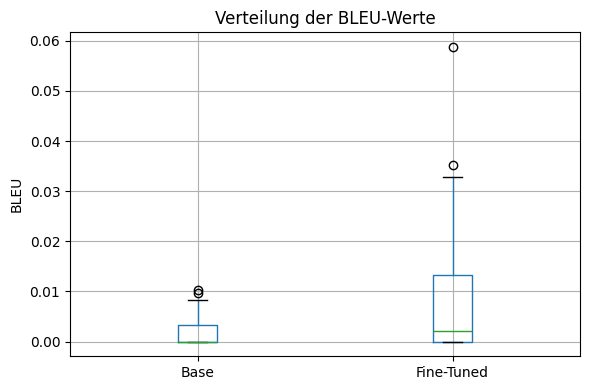

In [13]:
#BLEU Vergleich Boxplot Diagramm

bleu_box = pd.DataFrame({
    "Base": metrics["bleu_base"],
    "Fine-Tuned": metrics["bleu_ft"]
})

plt.figure(figsize=(6, 4))
bleu_box.boxplot()
plt.title("Verteilung der BLEU-Werte")
plt.ylabel("BLEU")
plt.tight_layout()
#plt.savefig("plots/bleu_boxplot.png", dpi=300)
plt.show()

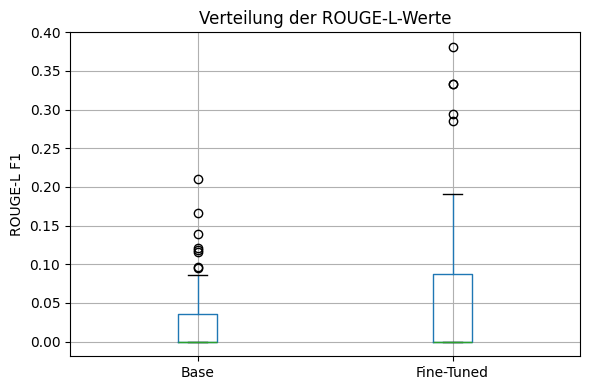

In [14]:
#ROUGE-L Vergleich Boxplot Diagramm

rouge_box = pd.DataFrame({
    "Base": metrics["rougeL_base"],
    "Fine-Tuned": metrics["rougeL_ft"]
})

plt.figure(figsize=(6, 4))
rouge_box.boxplot()
plt.title("Verteilung der ROUGE-L-Werte")
plt.ylabel("ROUGE-L F1")
plt.tight_layout()
plt.show()

In [15]:
#Nach Vertrauenslevel sortieren- trust als dict index

if "trust" in metrics.columns:
    trust_summary = metrics.groupby("trust").agg({
        "bertscore_f1_base": "mean",
        "bertscore_f1_ft": "mean",
        "bleu_base": "mean",
        "bleu_ft": "mean",
        "rougeL_base": "mean",
        "rougeL_ft": "mean",
        "len_reference_tokens": "mean",
        "len_base_tokens": "mean",
        "len_ft_tokens": "mean"
    }).reset_index()

    trust_summary

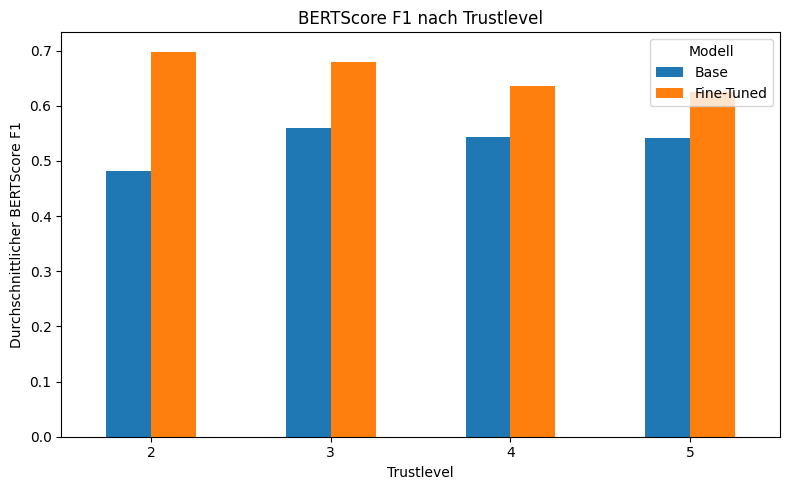

In [16]:
#Plot der Vertrauenslevel nach F1 Score, falls Daten verfügbar
if "trust" in metrics.columns:
    plot_df = trust_summary.set_index("trust")[["bertscore_f1_base", "bertscore_f1_ft"]]
    plot_df.columns = ["Base", "Fine-Tuned"]

    ax = plot_df.plot(kind="bar", figsize=(8, 5))
    plt.title("BERTScore F1 nach Trustlevel")
    plt.ylabel("Durchschnittlicher BERTScore F1")
    plt.xlabel("Trustlevel")
    plt.xticks(rotation=0)
    plt.legend(title="Modell")
    plt.tight_layout()
    plt.show()

In [17]:
#Wilcoxon Signifikanz für die Metriken

def run_wilcoxon(base_col, ft_col, name):
    stat, p = wilcoxon(metrics[ft_col], metrics[base_col])
    print(f"{name}")
    print("Wilcoxon statistic:", stat)
    print("p-value:", p)
    print()

run_wilcoxon("bertscore_f1_base", "bertscore_f1_ft", "BERTScore F1")
run_wilcoxon("bleu_base", "bleu_ft", "BLEU")
run_wilcoxon("rougeL_base", "rougeL_ft", "ROUGE-L")

BERTScore F1
Wilcoxon statistic: 210.0
p-value: 1.7242622413327714e-15

BLEU
Wilcoxon statistic: 354.5
p-value: 5.691715200928442e-07

ROUGE-L
Wilcoxon statistic: 410.0
p-value: 0.0015505413916494955



In [ ]:
#Beste Beispielanalyse

best_ft = metrics.sort_values("delta_bertscore_f1", ascending=False).head(3)

for _, row in best_ft.iterrows():
    print("\n---")
    print("INPUT:", row["input"])
    print("REFERENCE:", row["reference"])
    print("BASE:", row["base_answer"])
    print("FT:", row["ft_answer"])
    print("Δ BERTScore:", row["delta_bertscore_f1"])

In [ ]:
#Schlechteste Beispielanalyse

worst_ft = metrics.sort_values("delta_bertscore_f1", ascending=True).head(3)

for _, row in worst_ft.iterrows():
    print("\n---")
    print("INPUT:", row["input"])
    print("REFERENCE:", row["reference"])
    print("BASE:", row["base_answer"])
    print("FT:", row["ft_answer"])
    print("Δ BERTScore:", row["delta_bertscore_f1"])

In [20]:
#Nicht leere Zeilen zählen

def count_non_empty_lines(text):

    text = str(text)
    lines = text.splitlines()
    non_empty_lines = [line for line in lines if line.strip()]
    return len(non_empty_lines)

In [22]:
#Nicht leere Zeilen in Quartilen überprüfen

import pandas as pd
import numpy as np

metrics = pd.read_csv("eval_metrics_100_2.csv")

metrics["lines_reference"] = metrics["reference"].apply(count_non_empty_lines)
metrics["lines_base"] = metrics["base_answer"].apply(count_non_empty_lines)
metrics["lines_ft"] = metrics["ft_answer"].apply(count_non_empty_lines)

metrics[[
    "lines_reference",
    "lines_base",
    "lines_ft"
]].describe()

,lines_reference,lines_base,lines_ft
count,100.000000,100.000000,100.000000
mean,2.240000,8.830000,2.200000
std,1.837433,5.120872,2.678006
min,1.000000,1.000000,1.000000
25%,1.000000,5.000000,1.000000
50%,2.000000,9.000000,1.000000
75%,3.000000,12.000000,2.000000
max,11.000000,21.000000,16.000000


In [23]:
#Zeilenvergleich

line_summary = pd.DataFrame({
    "Metrik": ["Zeilenanzahl"],
    "Referenz": [metrics["lines_reference"].mean()],
    "Base": [metrics["lines_base"].mean()],
    "Fine-Tuned": [metrics["lines_ft"].mean()]
})

line_summary

,Metrik,Referenz,Base,Fine-Tuned
0,Zeilenanzahl,2.24,8.83,2.2


In [24]:
#Absolute Zeilendifferenz

metrics["abs_line_diff_base"] = (
    metrics["lines_base"] - metrics["lines_reference"]
).abs()

metrics["abs_line_diff_ft"] = (
    metrics["lines_ft"] - metrics["lines_reference"]
).abs()

print("absolute Zeilendifferenz Base:", metrics["abs_line_diff_base"].mean())
print("absolute Zeilendifferenz Fine-Tuned:", metrics["abs_line_diff_ft"].mean())

absolute Zeilendifferenz Base: 6.79
absolute Zeilendifferenz Fine-Tuned: 2.04


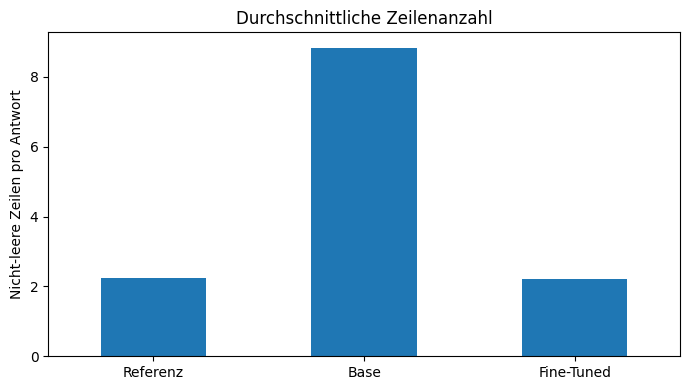

In [25]:
#Plot der durschnittlichen Zeilenanzahl
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)

line_means = pd.Series({
    "Referenz": metrics["lines_reference"].mean(),
    "Base": metrics["lines_base"].mean(),
    "Fine-Tuned": metrics["lines_ft"].mean()
})

plt.figure(figsize=(7, 4))
line_means.plot(kind="bar")
plt.title("Durchschnittliche Zeilenanzahl")
plt.ylabel("Nicht-leere Zeilen pro Antwort")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

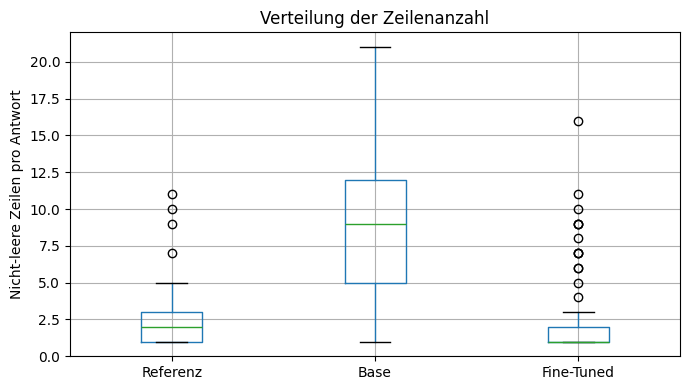

In [26]:
#Plot der Zeilenanzahlsverteilung
line_box = pd.DataFrame({
    "Referenz": metrics["lines_reference"],
    "Base": metrics["lines_base"],
    "Fine-Tuned": metrics["lines_ft"]
})

plt.figure(figsize=(7, 4))
line_box.boxplot()
plt.title("Verteilung der Zeilenanzahl")
plt.ylabel("Nicht-leere Zeilen pro Antwort")
plt.tight_layout()
plt.savefig("plots/line_count_boxplot.png", dpi=300)
plt.show()

In [27]:
import peft
print(peft.__version__)

0.18.0
